### 1. EMA crossover

Long only.

Let $s_t=\mathbf 1\{\mathrm{EMA}_{21}(P)_t>\mathrm{EMA}_{50}(P)_t\}$.

**Entry.** Go long at the close of day $t$ when $s_t-s_{t-1}=+1$, the day the fast average crosses
above the slow one. Set the stop at $P_t(1-0.05)$.

**Exit.** At the close of the first day on which either
* $s_t-s_{t-1}=-1$, the fast average crosses back below the slow one, or
* $P_t$ is below the stop.
---

### 2. MACD crossover

Long and short.

Let $H$ be the MACD histogram, the MACD line minus its signal line, and
$g_t=\operatorname{sign}(H)_t-\operatorname{sign}(H)_{t-1}$.

**Entry.** Long at the close when $g_t=+1$, the histogram crossing up through zero. Short when
$g_t=-1$. A signal in the opposite direction reverses the position.

**Exit.** On the trailing stop, width $w=|\bar r|+\sigma_r$ in per cent. Unlike rule 1 this stop is
monotone: it only ever tightens.

---

### 3. RSI, VWAP and ADX

Long and short.

Write $C^{\mathrm{RSI}}=\operatorname{sign}(\mathrm{RSI}-\mathrm{RSI}_{\mathrm{MA}})$,
$C^{\mathrm{VWAP}}=\operatorname{sign}(P-\mathrm{VWAP})$ and
$C^{\mathrm{ADX}}=\operatorname{sign}\big(\mathrm{ADX}-(\mu_{\mathrm{ADX}}-\sigma_{\mathrm{ADX}})\big)$.

**Entry.** Long at the close when all three hold at once:
* $\operatorname{sign}(H_t-H_{t-1})=+1$, the MACD histogram rising,
* $\operatorname{sign}(r_t)=+1$, the day's return positive,
* $C^{\mathrm{RSI}}+C^{\mathrm{VWAP}}+C^{\mathrm{ADX}}=3$, all three confirming.

Short at the mirror, with $-1$, $-1$ and $-3$.

**Exit.** Long closes when $C^{\mathrm{VWAP}}=-1$ **or** $C^{\mathrm{ADX}}=-1$. Short closes when
either turns $+1$. There is no stop. The position carries forward between entry and exit, and on a
day that both enters and exits, the exit wins.

---

### 4. Double Bollinger, range bounded

Long and short.

Let $M$ be the SMA(20) and $\sigma$ the rolling standard deviation over the same window.

**Entry, long.** Arm the rule once the close falls below $M-2\sigma$. Once armed, enter at the close
of the first day on which the close crosses back up through $M-\sigma$. Entering disarms it.

**Entry, short.** The mirror: arm above $M+2\sigma$, enter on the cross back down through
$M+\sigma$.

**Exit.** Long closes when the close crosses up through the middle band $M$. Short closes when it
crosses down through $M$. There is no stop.

In [23]:
import sys
from pathlib import Path
_start = Path(globals().get("__vsc_ipynb_file__", Path.cwd())).resolve()
_start = _start.parent if _start.is_file() else _start
ROOT = next(p for p in [_start, *_start.parents] if (p / "src" / "config.py").is_file())
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import backtest as bt
import config
import data
import strategy as st

plt.rcParams.update({"font.family": "serif", "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.3})

TICKERS = [t for t, _ in config.UNIVERSE]
SHOWN = "^GSPC"
STOP_LOSS = 0.05

COLUMNS = ["trades", "time_in_market", "win_rate", "profit_factor",
           "mean_trade_pct", "sd_trade_pct", "strategy_cagr", "hold_cagr",
           "cagr_alpha", "max_drawdown", "sharpe"]


def ema_rule(df):
    """Entry on the fast average crossing above the slow one, exit on the
    opposite cross or the five per cent stop."""
    close = df["Adj Close"]
    _, trigger = st.ema_state(close)
    trades = bt.run(close, trigger, STOP_LOSS)
    return bt.positions_from_trades(close, trades), trades


def macd_rule(df):
    """Entry on the histogram crossing zero, either way, exit on the monotone
    trailing stop."""
    close = df["Adj Close"]
    signal = st.macd_signal(close).fillna(0)
    stop = st.trailing_stop(close, signal, st.stop_width(close))
    position = stop["long"].astype(float) - stop["short"].astype(float)
    return position, bt.from_positions(close, position)


def confirmation_rule(df):
    """Entry when the histogram rises, the day is up and RSI, VWAP and ADX all
    confirm, exit when the VWAP or the ADX condition turns."""
    close = df["Adj Close"]
    position = st.confirmation(close, df["High"], df["Low"], df["Volume"])
    return position, bt.from_positions(close, position)


def bollinger_rule(df):
    """Entry on the close returning through the inner band after leaving the
    outer one, exit at the middle band."""
    close = df["Adj Close"]
    position = st.bollinger_reversion(close)
    return position, bt.from_positions(close, position)


RULES = {"EMA crossover": ema_rule,
         "MACD crossover": macd_rule,
         "RSI, VWAP and ADX": confirmation_rule,
         "Double Bollinger": bollinger_rule}

print(f"{len(RULES)} rules, {len(TICKERS)} tickers, {config.START} to {config.END}")

4 rules, 20 tickers, 2015-01-01 to 2026-09-16


## Run

Every rule over every ticker, one download pass.

In [24]:
frames = {}
for ticker in TICKERS:
    df = data.prices(ticker)
    if df.empty:
        print(f"no data for {ticker}")
        continue
    frames[ticker] = df

tables, positions, history = {}, {}, {}
for name, rule in RULES.items():
    rows, pos, hist = {}, {}, {}
    for ticker, df in frames.items():
        close = df["Adj Close"]
        position, trades = rule(df)
        pos[ticker], hist[ticker] = position, trades
        rows[ticker] = bt.measures(close, position, trades)
    tables[name] = pd.DataFrame(rows).T[COLUMNS]
    positions[name], history[name] = pos, hist

## Results

One table per rule, one row per ticker. `cagr_alpha` is the strategy's
annual growth less that of holding the same index over the same window.

In [25]:
for name, table in tables.items():
    print(name)
    display(table.round(2))

EMA crossover


,trades,time_in_market,win_rate,profit_factor,mean_trade_pct,sd_trade_pct,strategy_cagr,hold_cagr,cagr_alpha,max_drawdown,sharpe
^AEX,30.0,0.68,40.00,1.96,1.61,8.19,2.78,8.49,-5.71,-23.90,0.30
XU030.IS,29.0,0.56,31.03,3.43,5.82,23.16,11.55,26.56,-15.01,-34.44,0.66
^BFX,30.0,0.64,26.67,0.73,-0.53,6.60,-1.65,4.87,-6.52,-46.44,-0.09
^FCHI,32.0,0.65,34.38,0.89,-0.09,6.68,-0.71,5.65,-6.36,-34.41,-0.00
2823.HK,6.0,0.69,33.33,0.98,0.33,9.96,1.98,14.35,-12.36,-30.26,0.20
^GDAXI,27.0,0.68,37.04,1.57,1.45,7.77,1.90,8.51,-6.61,-31.93,0.21
EXSG.DE,31.0,0.65,29.03,1.33,1.21,10.46,1.73,7.95,-6.22,-39.29,0.21
YM=F,28.0,0.74,46.43,2.40,2.03,7.53,5.12,9.66,-4.53,-18.45,0.51
^IXIC,26.0,0.76,50.00,3.42,4.19,11.98,8.63,15.68,-7.05,-22.53,0.64
^GSPC,22.0,0.78,45.45,3.64,4.21,11.69,8.59,11.79,-3.20,-23.97,0.78


MACD crossover


,trades,time_in_market,win_rate,profit_factor,mean_trade_pct,sd_trade_pct,strategy_cagr,hold_cagr,cagr_alpha,max_drawdown,sharpe
^AEX,247.0,0.53,36.03,1.04,0.06,2.22,0.62,8.49,-7.87,-26.14,0.11
XU030.IS,239.0,0.50,37.24,1.36,0.50,4.38,8.08,26.56,-18.47,-28.23,0.52
^BFX,251.0,0.50,37.85,1.15,0.16,2.38,2.82,4.87,-2.05,-30.55,0.30
^FCHI,235.0,0.54,42.55,1.15,0.12,2.26,1.87,5.65,-3.78,-23.13,0.22
2823.HK,58.0,0.60,25.86,0.74,-0.34,4.35,-10.45,14.35,-24.80,-44.62,-0.45
^GDAXI,263.0,0.55,36.88,0.96,-0.00,2.14,-0.97,8.51,-9.48,-35.07,-0.02
EXSG.DE,235.0,0.59,42.55,1.64,0.42,2.75,7.87,7.95,-0.08,-20.86,0.73
YM=F,247.0,0.60,40.08,1.27,0.22,2.06,4.26,9.66,-5.40,-23.23,0.44
^IXIC,251.0,0.54,35.46,0.88,-0.10,2.34,-3.32,15.68,-19.00,-54.88,-0.19
^GSPC,257.0,0.57,39.30,1.07,0.07,2.05,0.81,11.79,-10.99,-32.72,0.13


RSI, VWAP and ADX


,trades,time_in_market,win_rate,profit_factor,mean_trade_pct,sd_trade_pct,strategy_cagr,hold_cagr,cagr_alpha,max_drawdown,sharpe
^AEX,155.0,0.53,51.61,1.11,0.15,3.17,1.35,8.49,-7.15,-36.99,0.18
XU030.IS,150.0,0.49,55.33,1.89,1.13,5.84,13.39,26.56,-13.17,-25.38,0.82
^BFX,146.0,0.42,50.68,1.16,0.14,2.23,1.52,4.87,-3.35,-31.92,0.21
^FCHI,151.0,0.52,45.03,0.78,-0.21,3.34,-3.41,5.65,-9.06,-45.12,-0.24
2823.HK,35.0,0.42,42.86,1.10,0.13,2.70,1.39,14.35,-12.96,-29.67,0.17
^GDAXI,155.0,0.50,50.32,0.94,-0.00,3.37,-0.37,8.51,-8.89,-43.13,0.03
EXSG.DE,139.0,0.49,56.83,1.56,0.41,3.38,4.18,7.95,-3.77,-29.61,0.47
YM=F,154.0,0.53,56.49,1.12,0.13,2.81,1.45,9.66,-8.20,-35.78,0.19
^IXIC,162.0,0.58,54.94,1.36,0.37,2.89,4.80,15.68,-10.88,-22.03,0.38
^GSPC,169.0,0.56,60.95,1.13,0.14,2.87,1.45,11.79,-10.34,-38.89,0.18


Double Bollinger


,trades,time_in_market,win_rate,profit_factor,mean_trade_pct,sd_trade_pct,strategy_cagr,hold_cagr,cagr_alpha,max_drawdown,sharpe
^AEX,106.0,0.26,75.47,1.97,0.53,1.86,4.65,8.49,-3.84,-12.13,0.64
XU030.IS,99.0,0.33,65.66,0.66,-0.56,5.13,-5.56,26.56,-32.12,-59.13,-0.33
^BFX,111.0,0.31,72.97,1.76,0.48,2.03,4.44,4.87,-0.43,-16.87,0.52
^FCHI,105.0,0.26,77.14,1.64,0.44,2.32,3.95,5.65,-1.71,-15.73,0.50
2823.HK,21.0,0.22,76.19,4.08,1.24,2.80,10.81,14.35,-3.54,-8.02,1.08
^GDAXI,111.0,0.28,77.48,1.93,0.53,1.95,5.16,8.51,-3.35,-12.74,0.60
EXSG.DE,100.0,0.27,74.00,1.89,0.49,1.96,4.13,7.95,-3.82,-12.93,0.55
YM=F,91.0,0.28,68.13,1.04,0.05,2.19,0.34,9.66,-9.31,-31.40,0.09
^IXIC,92.0,0.30,58.70,0.62,-0.53,3.39,-4.77,15.68,-20.45,-57.90,-0.29
^GSPC,95.0,0.28,72.63,1.08,0.09,2.37,0.44,11.79,-11.35,-29.28,0.10


## Capital

All four rules and holding the index, same starting capital, one name.

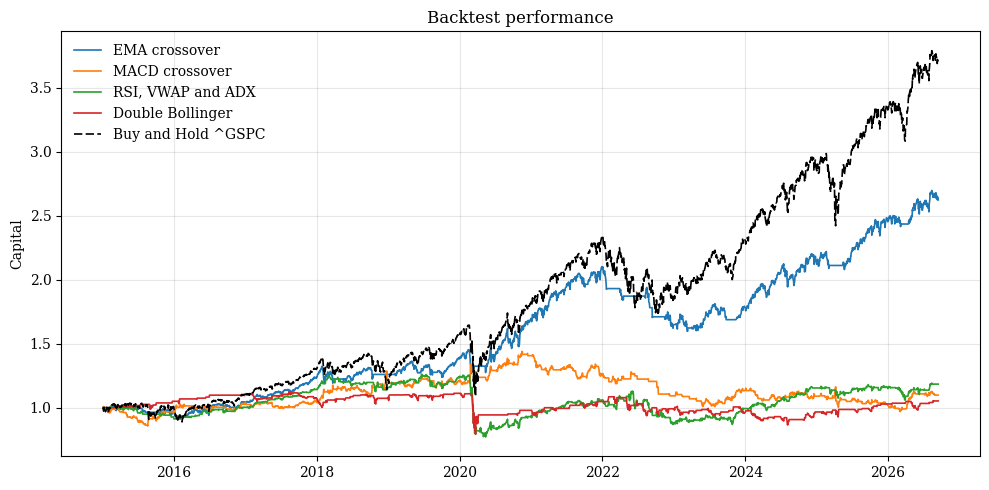

In [26]:
close = frames[SHOWN]["Adj Close"]

fig, ax = plt.subplots(figsize=(10, 5))
for name in RULES:
    equity, _ = bt.daily_equity(close, positions[name][SHOWN])
    ax.plot(equity/ 100000.0, linewidth=1.2, label=name)
ax.plot(close / close.iloc[0], linewidth=1.2, color="black",
        linestyle=(0, (5, 2)), label=f"Buy and Hold {SHOWN}")
ax.set_ylabel("Capital")
ax.set_title(f"Backtest performance")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(ROOT / "capital.png", dpi=150) 
plt.tight_layout()
plt.show()

## Trades

The trade list behind each rule for the same name. `side` is $+1$ long,
$-1$ short.

In [27]:
for name in RULES:
    print(f"{name}, {SHOWN}")
    h = history[name][SHOWN]
    display(h.round({col: 2 for col in h.select_dtypes("number").columns}))

EMA crossover, ^GSPC


,opened,closed,side,open_price,close_price,shares,pnl,equity,pnl_pct
0,2015-02-12,2015-06-30,1.0,2088.48,2063.11,47,-1192.38,98807.62,-1.19
1,2015-07-20,2015-07-27,1.0,2128.28,2067.64,46,-2789.45,96018.17,-2.82
2,2015-07-29,2015-08-06,1.0,2108.57,2083.56,45,-1125.45,94892.72,-1.17
3,2015-10-22,2016-01-05,1.0,2052.51,2016.71,46,-1646.80,93245.92,-1.74
4,2016-03-09,2016-10-13,1.0,1989.26,2132.55,46,6591.34,99837.26,7.07
5,2016-11-16,2018-03-23,1.0,2176.94,2588.26,45,18509.40,118346.66,18.54
6,2018-05-14,2018-10-15,1.0,2730.13,2750.79,43,888.39,119235.05,0.75
7,2019-02-04,2019-05-30,1.0,2724.87,2788.86,43,2751.57,121986.62,2.31
8,2019-06-12,2019-08-15,1.0,2879.84,2847.60,42,-1354.08,120632.54,-1.11
9,2019-09-09,2020-02-28,1.0,2978.43,2954.22,40,-968.40,119664.14,-0.80


MACD crossover, ^GSPC


,opened,closed,side,open_price,close_price,shares,pnl,equity,pnl_pct
0,2015-01-05,2015-01-08,-1.0,2020.58,2062.14,49,-2036.44,97963.56,-2.04
1,2015-01-22,2015-01-27,1.0,2063.15,2029.55,47,-1579.19,96384.37,-1.61
2,2015-01-29,2015-02-02,-1.0,2021.25,2020.85,47,18.80,96403.17,0.02
3,2015-02-03,2015-03-04,1.0,2050.03,2098.53,47,2279.50,98682.67,2.36
4,2015-03-04,2015-03-12,-1.0,2098.53,2065.95,47,1531.26,100213.93,1.55
...,...,...,...,...,...,...,...,...,...
252,2026-05-18,2026-05-21,-1.0,7403.05,7445.72,15,-640.06,114892.60,-0.55
253,2026-07-06,2026-07-17,1.0,7537.43,7457.69,15,-1196.10,113696.49,-1.04
254,2026-07-17,2026-07-30,-1.0,7457.69,7437.63,15,300.90,113997.39,0.26
255,2026-08-03,2026-08-18,1.0,7600.50,7691.76,14,1277.64,115275.03,1.12


RSI, VWAP and ADX, ^GSPC


,opened,closed,side,open_price,close_price,shares,pnl,equity,pnl_pct
0,2015-02-05,2015-03-04,1.0,2062.52,2098.53,48,1728.48,101728.48,1.73
1,2015-03-20,2015-03-25,1.0,2108.10,2061.05,48,-2258.40,99470.08,-2.22
2,2015-04-01,2015-04-02,-1.0,2059.69,2066.96,48,-348.96,99121.12,-0.35
3,2015-04-10,2015-04-22,1.0,2102.06,2107.96,47,277.30,99398.41,0.28
4,2015-05-08,2015-05-18,1.0,2116.10,2129.20,46,602.59,100001.01,0.61
...,...,...,...,...,...,...,...,...,...
164,2026-04-13,2026-04-30,1.0,6886.24,7209.01,15,4841.54,113922.09,4.44
165,2026-05-08,2026-05-18,1.0,7398.93,7403.05,15,61.79,113983.88,0.05
166,2026-05-27,2026-06-16,1.0,7520.36,7511.35,15,-135.15,113848.74,-0.12
167,2026-06-30,2026-07-08,1.0,7499.36,7482.71,15,-249.75,113598.99,-0.22


Double Bollinger, ^GSPC


,opened,closed,side,open_price,close_price,shares,pnl,equity,pnl_pct
0,2015-03-16,2015-03-18,1.0,2081.19,2099.50,48,878.88,100878.88,0.88
1,2015-06-10,2015-06-18,1.0,2105.20,2121.24,47,753.88,101632.76,0.75
2,2015-07-07,2015-07-13,1.0,2081.34,2099.60,48,876.48,102509.25,0.86
3,2015-08-27,2015-09-15,1.0,1987.66,1978.09,51,-488.07,102021.17,-0.48
4,2015-09-30,2015-10-02,1.0,1920.03,1951.36,53,1660.49,103681.66,1.63
...,...,...,...,...,...,...,...,...,...
90,2026-03-31,2026-04-06,1.0,6528.52,6611.83,15,1249.65,105442.00,1.20
91,2026-04-29,2026-06-05,-1.0,7135.95,7383.74,14,-3469.06,101972.94,-3.29
92,2026-06-11,2026-06-15,1.0,7394.30,7554.29,13,2079.87,104052.82,2.04
93,2026-07-30,2026-07-31,1.0,7437.63,7489.72,13,677.17,104729.99,0.65
